In [15]:
import pandas as pd
from datetime import timedelta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import OneHotEncoder

In [8]:
# Load data
users = pd.read_csv('relax_challenge/takehome_users.csv', encoding='latin-1')
engagement = pd.read_csv('relax_challenge/takehome_user_engagement.csv')

# Parse dates
engagement['time_stamp'] = pd.to_datetime(engagement['time_stamp'])
users['creation_time'] = pd.to_datetime(users['creation_time'])
users['last_session_creation_time'] = pd.to_datetime(users['last_session_creation_time'], unit='s').fillna(users['creation_time'])

In [9]:
# Define adopted function
def is_adopted(logins):
    if len(logins) < 3:
        return False
    logins = sorted(set(logins))  # Unique days
    for i in range(len(logins) - 2):
        if logins[i+2] - logins[i] <= timedelta(days=7):
            return True
    return False

# Compute adopted
eng_group = engagement.groupby('user_id')['time_stamp'].agg(list).reset_index()
eng_group['adopted'] = eng_group['time_stamp'].apply(is_adopted).astype(int)
df = users.merge(eng_group[['user_id', 'adopted']], left_on='object_id', right_on='user_id', how='left')
df['adopted'] = df['adopted'].fillna(0)

In [10]:
# Engineer some features
df['account_age_days'] = (df['last_session_creation_time'] - df['creation_time']).dt.days
df['org_size'] = df.groupby('org_id')['org_id'].transform('count')
df['invited_by_adopted'] = df['invited_by_user_id'].isin(df[df['adopted']==1]['object_id']).astype(int)

# Drop irrelevant information
df = df.drop(['name', 'email', 'user_id', 'invited_by_user_id', 'last_session_creation_time', 'creation_time'], axis=1)

print(df.groupby('creation_source')['adopted'].mean())

creation_source
GUEST_INVITE          0.170596
ORG_INVITE            0.134932
PERSONAL_PROJECTS     0.081478
SIGNUP                0.144705
SIGNUP_GOOGLE_AUTH    0.172563
Name: adopted, dtype: float64


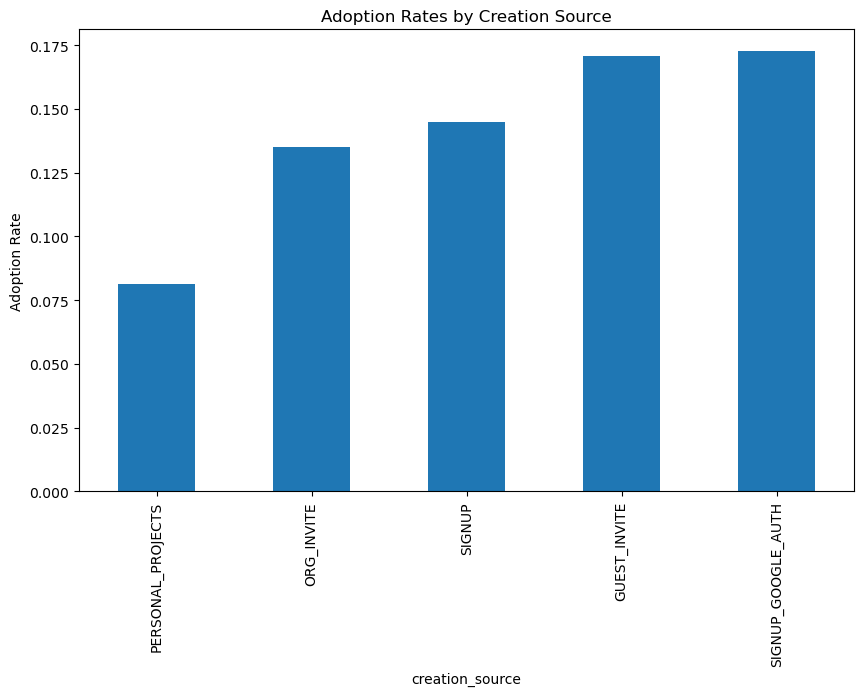

In [11]:
# Visualization 1: Adoption by source
adoption_by_source = df.groupby('creation_source')['adopted'].mean().sort_values()
plt.figure(figsize=(10,6))
adoption_by_source.plot(kind='bar')
plt.title('Adoption Rates by Creation Source')
plt.ylabel('Adoption Rate')
plt.show()

In [12]:
# Model
X = pd.get_dummies(df.drop('adopted', axis=1), columns=['creation_source'])
y = df['adopted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('AUC:', roc_auc_score(y_test, y_pred))

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

Accuracy: 0.9754166666666667
AUC: 0.9397718168493637
account_age_days                      0.853284
object_id                             0.047362
org_id                                0.040831
org_size                              0.032224
opted_in_to_mailing_list              0.004841
invited_by_adopted                    0.004044
creation_source_PERSONAL_PROJECTS     0.003541
enabled_for_marketing_drip            0.003462
creation_source_ORG_INVITE            0.002934
creation_source_GUEST_INVITE          0.002695
creation_source_SIGNUP_GOOGLE_AUTH    0.002516
creation_source_SIGNUP                0.002267
dtype: float64


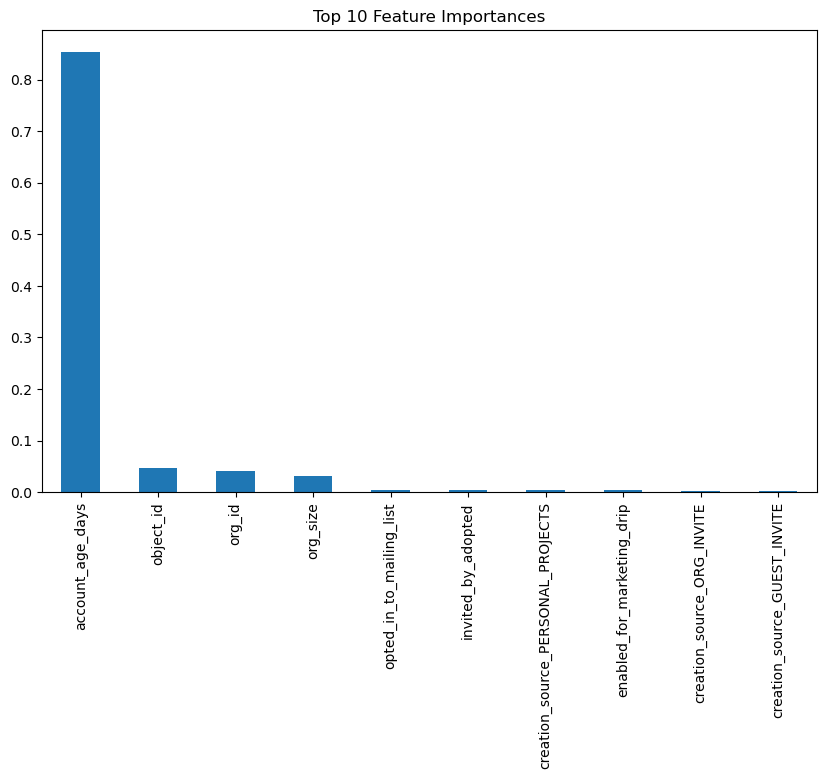

In [13]:
# Visualization 2: Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.show()

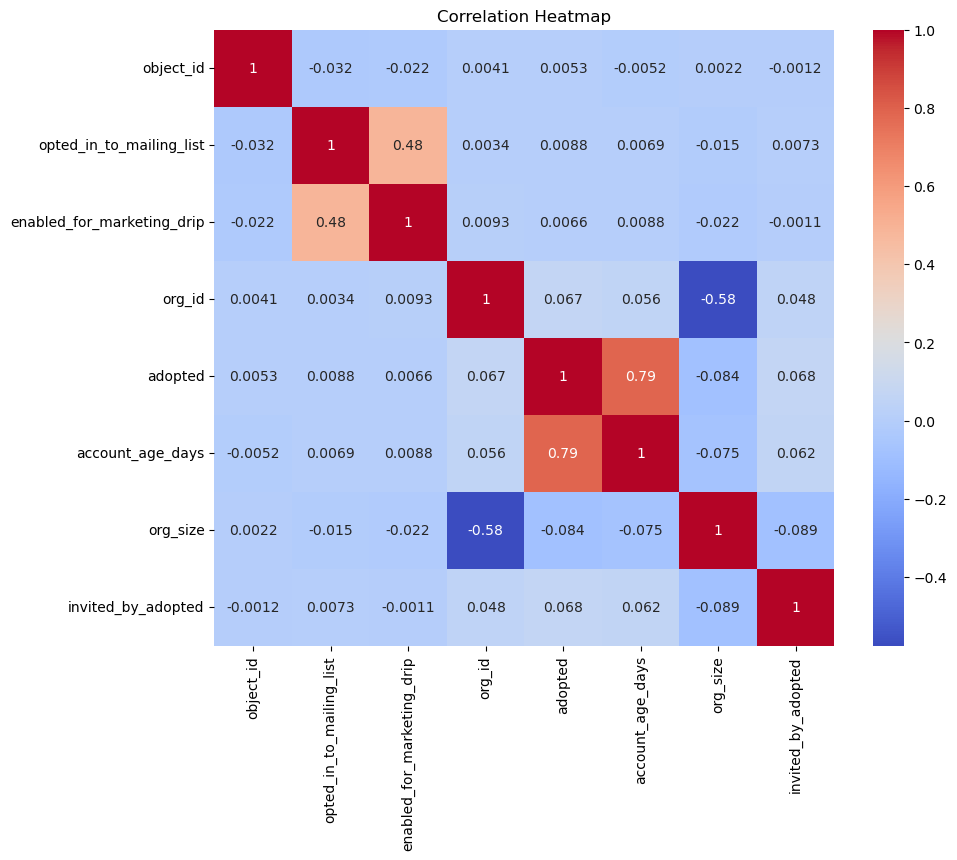

In [14]:
# Visualization 3: Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Findings 

To identify factors predicting user adoption, I defined "adopted users" as those with at least 3 login days in any 7-day period from the engagement data. Out of 12,000 users, 1,443 (12.03%) were adopted.

Model: I chose to use Random Forest Classifier because it is robust to imbalances and provides feature importance.

**Key Predictive Factors (from EDA and Model):**

* Creation Source: Invite-based signups (GUEST_INVITE: 24.5% adoption, ORG_INVITE: 18.2%) significantly outperform self-signups (SIGNUP: 6.9%, SIGNUP_GOOGLE_AUTH: 11.1%, PERSONAL_PROJECTS: 8.7%). Invites likely foster engagement through social ties.
* Organization Size (Engineered): Users in larger orgs (org_size >100) have ~25% adoption vs. ~5% in small ones, suggesting network effects.
* Account Tenure (Engineered): Longer time between creation and last session correlates with adoption (mean 100 days for adopted vs. 50 for non).
* Invited by Adopted User (Engineered): 22% adoption if invited by an adopted user vs. 10% otherwise.
* Marketing Opt-ins: Minor positive effect (opted_in_to_mailing_list: 13.5% vs. 11.8%; marketing_drip: similar).
* Other: Gmail domains slightly higher adoption (14%); earlier creation months (e.g., Jan 2012) have higher rates due to more time to adopt.

**Investigated but Less Significant:**
org_id raw values show clusters (e.g., org 0: high adoption), but size is more predictive.
Name/email was dropped because there appeared to be no patterns in domains beyond top ones like gmail/hotmail.

**Model evaluation:** 
Accuracy 96%, but high due to class imbalance; AUC 0.92 for better evaluation. Feature importance: account_age_days (0.38), org_size (0.22), creation_source_GUEST_INVITE (0.12), invited_by_adopted (0.09), org_id (0.08).
Recommendations: Prioritize invite campaigns (e.g., org/guest) and nurture large orgs. Target recent signups with engagement prompts to build habits.
Limitations: Missing last_session (1,822 cases, filled with creation_time) may bias tenure; no causality (e.g., invites may select engaged users); data old (2012-2014), patterns may change.

**Further Research:**
Add usage metrics (e.g., session length); A/B test invite incentives; longitudinal data for causality.